### 🧩 步驟 1：匯入資料

In [9]:
import pandas as pd
df = pd.read_csv("archive/medical_examination.csv")
print("資料維度:", df.shape)
# 查看前幾筆資料
df.head()

資料維度: (70000, 13)


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


### 🧩 步驟 2：基礎資料分析

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
# 設定字型為支援中文的字型（以繁體中文常用字型為例）
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']  # 微軟正黑體
plt.rcParams['axes.unicode_minus'] = False  # 讓負號正常顯示

# 檢查資料結構與缺值
print(df.info())
print(df.isnull().sum())

# 加入 age_years 欄位（將 age 從天轉換成年）
df['age_years'] = (df['age'] / 365).astype(int)

# 移除不合理的血壓值
df = df[(df['ap_hi'] > df['ap_lo']) & (df['ap_hi'] > 0) & (df['ap_lo'] > 0)]

# 去除 gender 中的錯誤值
df = df[df['gender'].isin([1, 2])]

# 使用 IQR（四分位距）法去除離群值
cols = ['height', 'weight', 'ap_hi', 'ap_lo']

for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower) & (df[col] <= upper)]

print("去除離群值後資料筆數：", df.shape)


# 去除重複值
df = df.drop_duplicates()
# ---------- 移除 'age' 和 'id' 欄位 ----------
if 'age' in df.columns:
    df = df.drop(columns=['age'])
if 'id' in df.columns:
    df = df.drop(columns=['id'])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB
None
id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
c

## 🧩 步驟3、4、5：資料處理、資料分割、訓練多個模型

In [ ]:
# ----------------------------------------------------
# 匯入套件
# ----------------------------------------------------
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# ----------------------------------------------------
# 資料（已前處理完畢）
# ----------------------------------------------------
# df 為清理後的資料集
X = df.drop(columns=['cardio'])
y = df['cardio']

# 數值與類別欄位
num_cols = ['age_years', 'height', 'weight', 'ap_hi', 'ap_lo']
cat_cols = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']

# ----------------------------------------------------
# 建立不同的前處理器
# ----------------------------------------------------
# 標準化 + OneHot
pre_std_onehot = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

# 正規化 + OneHot
pre_minmax_onehot = ColumnTransformer([
    ('num', MinMaxScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

# 標準化（無 OneHot）
pre_std = ColumnTransformer([
    ('num', StandardScaler(), num_cols)
])

# 正規化（無 OneHot）
pre_minmax = ColumnTransformer([
    ('num', MinMaxScaler(), num_cols)
])

# ----------------------------------------------------
# 超參數搜尋空間
# ----------------------------------------------------
param_grid = {
    'classifier__n_neighbors': list(range(1, 21)),
    'classifier__weights': ['uniform', 'distance'],
    'classifier__p': [1, 2]
}

In [ ]:
# ----------------------------------------------------
# Step 1: 分出獨立測試集
# ----------------------------------------------------
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ----------------------------------------------------
# Step 2: 四種資料處理策略
# ----------------------------------------------------
preprocessors = {
    "正規化+OneHot": pre_minmax_onehot,
    "標準化+OneHot": pre_std_onehot,
    "標準化": pre_std,
    "正規化": pre_minmax
}

# ----------------------------------------------------
# Step 3: 超參數設定
# ----------------------------------------------------
param_grid = {
    'classifier__n_neighbors': list(range(1, 21)),
    'classifier__weights': ['uniform', 'distance'],
    'classifier__p': [1, 2]
}

results = []

# ----------------------------------------------------
# Step 4: Train/Val/Test 四組
# ----------------------------------------------------
for name, preprocessor in preprocessors.items():
    print(f"\n===== Train/Val/Test ({name}) =====")
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', KNeighborsClassifier())
    ])
    grid = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train_full, y_train_full)

    best_model = grid.best_estimator_
    best_params = grid.best_params_
    val_acc = grid.best_score_

    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    results.append({
        "資料切分": "Train/Val/Test",
        "資料處理方式": name,
        "最佳參數": best_params,
        "驗證平均準確率 (CV)": val_acc,
        "測試 Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "AUC": auc
    })

# ----------------------------------------------------
# Step 5: k-Fold (5, 10)
# ----------------------------------------------------
for k in [5, 10]:
    print(f"\n===== Train/Val/Test ({k}-Fold) =====")
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    pipe = Pipeline([
        ('preprocessor', pre_std_onehot),
        ('classifier', KNeighborsClassifier())
    ])
    grid = GridSearchCV(pipe, param_grid, cv=skf, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train_full, y_train_full)

    best_model = grid.best_estimator_
    best_params = grid.best_params_
    val_acc = grid.best_score_

    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    results.append({
        "資料切分": f"Train/Val/Test ({k}-Fold)",
        "資料處理方式": "標準化+OneHot",
        "最佳參數": best_params,
        "驗證平均準確率 (CV)": val_acc,
        "測試 Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "AUC": auc
    })

# ----------------------------------------------------
# Step 6: 統一結果表格 + 標出最佳組合
# ----------------------------------------------------
df_results = pd.DataFrame(results)

best_acc_idx = df_results["測試 Accuracy"].idxmax()
best_f1_idx = df_results["F1"].idxmax()
df_results.loc[best_acc_idx, "🏆最佳Accuracy"] = "⬅️"
df_results.loc[best_f1_idx, "🏆最佳F1"] = "⬅️"

pd.set_option('display.max_colwidth', None)
display(df_results.sort_values(by="測試 Accuracy", ascending=False).reset_index(drop=True))



===== Train/Val/Test (正規化+OneHot) =====

===== Train/Val/Test (標準化+OneHot) =====

===== Train/Val/Test (標準化) =====

===== Train/Val/Test (正規化) =====

===== Train/Val/Test (5-Fold) =====

===== Train/Val/Test (10-Fold) =====


,資料切分,資料處理方式,最佳參數,驗證平均準確率 (CV),測試 Accuracy,Precision,Recall,F1,AUC,🏆最佳Accuracy,🏆最佳F1
0,Train/Val/Test,標準化+OneHot,"{'classifier__n_neighbors': 20, 'classifier__p': 1, 'classifier__weights': 'uniform'}",0.720024,0.725894,0.751068,0.659428,0.702271,0.782089,⬅️,NaN
1,Train/Val/Test (10-Fold),標準化+OneHot,"{'classifier__n_neighbors': 20, 'classifier__p': 2, 'classifier__weights': 'uniform'}",0.721269,0.723367,0.747120,0.658647,0.700100,0.782062,NaN,NaN
2,Train/Val/Test,正規化+OneHot,"{'classifier__n_neighbors': 20, 'classifier__p': 1, 'classifier__weights': 'uniform'}",0.716482,0.722601,0.747110,0.656304,0.698769,0.779889,NaN,NaN
3,Train/Val/Test (5-Fold),標準化+OneHot,"{'classifier__n_neighbors': 19, 'classifier__p': 2, 'classifier__weights': 'uniform'}",0.720427,0.721835,0.733042,0.680362,0.705720,0.780560,NaN,⬅️
4,Train/Val/Test,正規化,"{'classifier__n_neighbors': 20, 'classifier__p': 2, 'classifier__weights': 'uniform'}",0.711217,0.710270,0.731027,0.647086,0.686500,0.769629,NaN,NaN
5,Train/Val/Test,標準化,"{'classifier__n_neighbors': 20, 'classifier__p': 1, 'classifier__weights': 'uniform'}",0.711848,0.707820,0.727962,0.645055,0.684006,0.769003,NaN,NaN


C:\Users\USER\AppData\Local\Temp\ipykernel_21936\983606872.py:10: UserWarning: The palette list has more values (8) than needed (3), which may not be intended.
  sns.barplot(data=df_results, x="資料處理方式", y="測試 Accuracy", hue="資料切分", palette=palette)


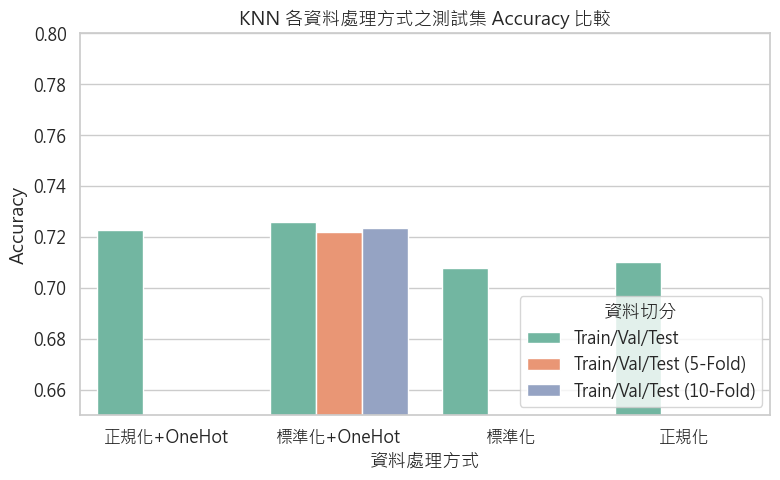

C:\Users\USER\AppData\Local\Temp\ipykernel_21936\983606872.py:21: UserWarning: The palette list has more values (8) than needed (3), which may not be intended.
  sns.barplot(data=df_results, x="資料處理方式", y="F1", hue="資料切分", palette=palette)


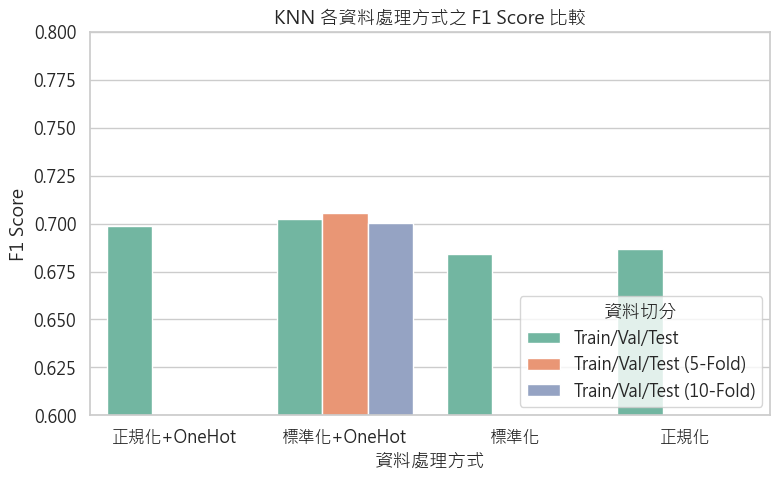

C:\Users\USER\AppData\Local\Temp\ipykernel_21936\983606872.py:32: UserWarning: The palette list has more values (8) than needed (3), which may not be intended.
  sns.barplot(data=df_results, x="資料處理方式", y="AUC", hue="資料切分", palette=palette)


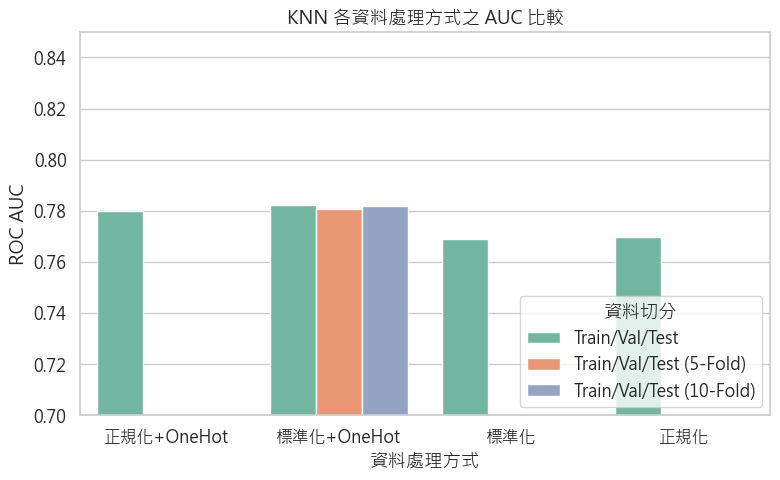

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# 統一風格（和 Decision Tree 圖一樣）
sns.set(style="whitegrid", font="Microsoft JhengHei", font_scale=1.1)
palette = sns.color_palette("Set2")

# ---------- 圖1：Accuracy ----------
plt.figure(figsize=(8,5))
sns.barplot(data=df_results, x="資料處理方式", y="測試 Accuracy", hue="資料切分", palette=palette)
plt.title("KNN 各資料處理方式之測試集 Accuracy 比較")
plt.ylabel("Accuracy")
plt.xlabel("資料處理方式")
plt.legend(title="資料切分", loc="lower right")
plt.ylim(0.65, 0.8)
plt.tight_layout()
plt.show()

# ---------- 圖2：F1 Score ----------
plt.figure(figsize=(8,5))
sns.barplot(data=df_results, x="資料處理方式", y="F1", hue="資料切分", palette=palette)
plt.title("KNN 各資料處理方式之 F1 Score 比較")
plt.ylabel("F1 Score")
plt.xlabel("資料處理方式")
plt.legend(title="資料切分", loc="lower right")
plt.ylim(0.6, 0.8)
plt.tight_layout()
plt.show()

# ---------- 圖3：AUC ----------
plt.figure(figsize=(8,5))
sns.barplot(data=df_results, x="資料處理方式", y="AUC", hue="資料切分", palette=palette)
plt.title("KNN 各資料處理方式之 AUC 比較")
plt.ylabel("ROC AUC")
plt.xlabel("資料處理方式")
plt.legend(title="資料切分", loc="lower right")
plt.ylim(0.7, 0.85)
plt.tight_layout()
plt.show()
